# 17 — Inventario de modelos y diagnóstico de entrenamiento frente a evaluación

Este notebook reúne las comparaciones existentes y reconstruye los últimos ajustes para medir su error de entrenamiento. **No mezcla el WAPE de entrenamiento con el WAPE retrospectivo de todo 2026.** Para cada ajuste se muestran train y test de su propio corte; por separado se conserva la evaluación completa de los notebooks originales.

Semanal vigente: ajuste del 3 de agosto de 2026, entrenamiento con objetivos cerrados antes del corte, evaluación en orígenes de agosto con comparación estricta. Modelos iniciales de 12: último corte, 4 de mayo de 2026, ocho semanas posteriores, sólo casos con teoría completa. Diario: último ajuste de agosto, ventana de entrenamiento de 104 semanas y días posteriores de agosto. SARIMA/SARIMAX: último origen del piloto, 365 días anteriores, tres series elegidas en 2025.

El error de entrenamiento es descriptivo dentro de muestra: el ajuste ya vio esos objetivos. Sus variables se construyeron con historia anterior a cada origen, pero sus parámetros se estimaron usando toda la ventana de entrenamiento. Un menor error de test que de train puede deberse a un mes más fácil o a composición distinta; no es por sí solo fuga de información. Para comparar algoritmos se mantienen los mismos casos dentro de cada tabla. El ingeniero no tiene train de nuestro algoritmo.

La teoría original y las referencias históricas son reglas, no estimadores ajustados. Los repartos diarios son transformaciones del total semanal y de pesos históricos o del boosting: su train es un diagnóstico del sistema compuesto, no un nuevo entrenamiento independiente. La corrección antigua anterior a calidad se conserva sólo como evidencia histórica y no se vuelve a entrenar con otra base.

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from threadpoolctl import threadpool_limits

ROOT = next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"Datos_analiticos_proyecto").is_dir())
SALIDA = ROOT/"Datos_analiticos_proyecto"

KEY=['finca','producto','color','variedad']
DESTINO=SALIDA/'modelo_con_proyecciones_teoricas'
integrados=pd.read_parquet(DESTINO/'base_analitica_proyecciones.parquet')
datos=integrados.loc[integrados.y.notna()&integrados.admisible_modelo].copy()
categoricas=['producto','color','variedad']
temporales=['horizonte','semana_seno','semana_coseno']
memoria=['produccion_lag1','produccion_lag2','produccion_lag3','media_4','media_8','desv_4','tendencia_4_8','cambio_reciente','produccion_52']
climaticas=[v+s for v in ['temperatura_semana','humedad_semana','radiacion_semana'] for s in ['_lag1','_media4']]
agronomicas=[]
X_columnas=categoricas+temporales+memoria+climaticas
X_teoria=X_columnas+['teoria_modelo','antiguedad_curva','desviacion_reciente_teoria']
X_historia=X_teoria+['teoria_previa_1','teoria_previa_2','revision_teoria']
assert 'y' not in X_historia
assert not integrados.duplicated(KEY+['origen','horizonte']).any()

from IPython.display import display
AUD=ROOT/'Notebooks/Proyecciones Teoricas Propias/resultados_todos_los_anios/auditoria_calidad'


In [2]:
CORTES = [pd.Timestamp("2025-07-07"),pd.Timestamp("2026-01-05"),pd.Timestamp("2026-05-04")]
SEMANAS_EVALUACION = 8

def crear_modelo(nombre,columnas):
    numericas = [c for c in columnas if c not in categoricas]
    numerico = make_pipeline(SimpleImputer(strategy="median",add_indicator=True,keep_empty_features=True),
                             StandardScaler()) if nombre.startswith("Ridge") else SimpleImputer(
                                 strategy="median",add_indicator=True,keep_empty_features=True)
    preparar = ColumnTransformer([
        ("categorias",OneHotEncoder(handle_unknown="ignore",sparse_output=False,dtype=np.float32),categoricas),
        ("numericas",numerico,numericas)])
    estimador = Ridge(alpha=100.0) if nombre.startswith("Ridge") else HistGradientBoostingRegressor(
        learning_rate=.08,max_iter=80,max_leaf_nodes=15,min_samples_leaf=40,
        l2_regularization=1.0,early_stopping=False,random_state=42)
    return make_pipeline(preparar,estimador)
print("Sesgo positivo = el modelo quedó por debajo de lo reportado.")
print("±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.")


Sesgo positivo = el modelo quedó por debajo de lo reportado.
±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.


In [3]:
llave=KEY+['origen','semana_objetivo','horizonte']
actual=pd.read_parquet(DESTINO/'comparacion_features_diarias_2026.parquet')
f=pd.read_parquet(SALIDA/'modelo_diario/features_diarias.parquet')
diarias=[c for c in f if c not in KEY+['fecha']]
integrados=integrados.merge(f.rename(columns={'fecha':'origen'}),on=KEY+['origen'],how='left',validate='many_to_one')
base=pd.read_parquet(DESTINO/'produccion_clima_semanal.parquet')
def memoria_larga(base):
    calendario=pd.DataFrame({'origen':pd.date_range(base.semana_inicio.min(),base.semana_inicio.max()+pd.Timedelta(weeks=1),freq='W-MON')})
    z=base[KEY].drop_duplicates().merge(calendario,how='cross').merge(base[KEY+['semana_inicio','tallos_reales']].rename(columns={'semana_inicio':'origen'}),on=KEY+['origen'],how='left',validate='one_to_one').sort_values(KEY+['origen'])
    g=z.groupby(KEY).tallos_reales
    z['media_12']=g.transform(lambda s:s.shift(1).rolling(12,min_periods=4).mean())
    for v in [8,12]:z[f'desv_{v}']=g.transform(lambda s:s.shift(1).rolling(v,min_periods=4).std())
    for v in [4,8,12]:z[f'reportes_{v}']=g.transform(lambda s:s.shift(1).rolling(v,min_periods=1).count())
    return z.drop(columns='tallos_reales')
extra=memoria_larga(base)
extra_cols=[c for c in extra if c not in KEY+['origen']]
integrados=integrados.merge(extra,on=KEY+['origen'],how='left',validate='many_to_one')
integrados['tendencia_4_12']=integrados.media_4-integrados.media_12
extra_cols+=['tendencia_4_12']
alterada=base.copy(); corte_prueba=pd.Timestamp('2025-01-06')
alterada.loc[alterada.semana_inicio.ge(corte_prueba),'tallos_reales']+=1000000
prueba=memoria_larga(alterada)
pd.testing.assert_frame_equal(extra.loc[extra.origen.le(corte_prueba)].reset_index(drop=True),prueba.loc[prueba.origen.le(corte_prueba)].reset_index(drop=True))
datos=integrados.loc[integrados.y.notna()&integrados.admisible_modelo].copy()
datos['grupo_h']=np.where(datos.horizonte.le(2),'H1_H2','H3_H5')
elegibles=datos.merge(actual[llave],on=llave,how='inner',validate='one_to_one')
assert len(elegibles)==len(actual)
Xbase=X_columnas+diarias
Xteoria=X_teoria+diarias
historia=['teoria_previa_1','teoria_previa_2','revision_teoria']
display(datos[extra_cols].isna().mean().mul(100).to_frame('faltantes_pct'))
print('Prueba temporal superada: alterar producción futura no cambia las variables disponibles al origen.')


,faltantes_pct
media_12,0.0
desv_8,0.0
desv_12,0.0
reportes_4,0.0
reportes_8,0.0
reportes_12,0.0
tendencia_4_12,0.0


Prueba temporal superada: alterar producción futura no cambia las variables disponibles al origen.


In [4]:
tablas=[]
def registrar(escenario,modelo,split,d,y,pred,fecha):
    y=np.asarray(y,dtype=float); pred=np.asarray(pred,dtype=float)
    assert len(y)==len(pred) and np.isfinite(y).all() and np.isfinite(pred).all()
    e=y-pred
    tablas.append({'escenario':escenario,'modelo':modelo,'split':split,'corte':fecha,'n':len(y),'inicio_origen':d.origen.min(),'fin_origen':d.origen.max(),'MAE':np.abs(e).mean(),'RMSE':np.sqrt(np.mean(e**2)),'WAPE':np.abs(e).sum()/y.sum(),'sesgo':e.mean()})
def ajustar(train,test,cols,referencia='media_4',nombre='Boosting',relativo=False,mae=False):
    model=crear_modelo(nombre,cols)
    if mae:model.steps[-1][1].set_params(loss='absolute_error')
    target=np.log1p(train.y)-np.log1p(train[referencia]) if relativo else train.y-train[referencia]
    with threadpool_limits(limits=2):
        model.fit(train[cols],target)
        salida=[]
        for d in [train,test]:
            resid=model.predict(d[cols])
            p=np.maximum(0,np.expm1(np.log1p(d[referencia])+resid)) if relativo else np.maximum(0,d[referencia]+resid)
            salida.append(pd.Series(np.asarray(p),index=d.index))
    return salida
def sistema(train,test,base,teoria,separar=False):
    pt=pd.Series(index=train.index,dtype=float);pv=pd.Series(index=test.index,dtype=float)
    grupos=['H1_H2','H3_H5'] if separar else ['todos']
    for g in grupos:
        tr=train.loc[train.grupo_h.eq(g)] if separar else train
        te=test.loc[test.grupo_h.eq(g)] if separar else test
        a,b=ajustar(tr,te,base)
        pt.loc[tr.index]=a;pv.loc[te.index]=b
        tc=tr.loc[tr.curva_completa];ec=te.loc[te.curva_completa]
        a,b=ajustar(tc,ec,teoria,referencia='teoria_modelo')
        pt.loc[tc.index]=a;pv.loc[ec.index]=b
    assert pt.notna().all() and pv.notna().all()
    return pt,pv
guardadas=pd.read_parquet(DESTINO/'experimentos_horizontes_2026.parquet')
te=elegibles.loc[elegibles.origen.dt.to_period('M').astype(str).eq('2026-08')].copy()
corte=te.origen.min();tr=datos.loc[(datos.semana_objetivo+pd.Timedelta(days=7)).le(corte)].copy()
comunes=guardadas.loc[guardadas.grupo_comparacion.eq('principal_estricta_nominal'),llave]
indices=te.reset_index().merge(comunes,on=llave,validate='one_to_one')['index']
train_pred={};test_pred={}
for nombre,xb,xt,separar in [('Sistema_anterior',X_columnas,X_teoria,False),('Sistema_diario',Xbase,Xteoria,False),('Separado',Xbase,Xteoria,True),('Memoria_larga',Xbase+extra_cols,Xteoria+extra_cols,True),('Revisiones',Xbase+extra_cols+historia,Xteoria+extra_cols+historia,True)]:
    a,b=sistema(tr,te,xb,xt,separar)
    train_pred[nombre]=a;test_pred[nombre]=b
    print('Reconstruido semanal',nombre,flush=True)
a,b=ajustar(tr,te,Xteoria,relativo=True)
train_pred['Ajuste_relativo_diario']=a;test_pred['Ajuste_relativo_diario']=b
cols_mae=categoricas+temporales+memoria+['teoria_modelo','antiguedad_curva','desviacion_reciente_teoria','curva_completa']+climaticas+diarias
a,b=ajustar(tr,te,cols_mae,mae=True)
train_pred['Boosting_diario_MAE']=a;test_pred['Boosting_diario_MAE']=b
pesos=pd.read_excel(DESTINO/'resultados_experimentos_horizontes.xlsx',sheet_name='Pesos_pre2026').set_index('grupo')
for d,preds in [(tr,train_pred),(te,test_pred)]:
    comb=preds['Revisiones'].copy()
    for grupo,g in d.groupby('grupo_h'):
        w=pesos.loc[grupo];ref=g.media_4 if w.referencia=='media_4' else g.teoria_modelo.where(g.curva_completa,g.media_4)
        comb.loc[g.index]=w.peso_modelo*preds['Revisiones'].loc[g.index]+(1-w.peso_modelo)*ref
    preds['Combinacion']=comb
for nombre in train_pred:
    origen=guardadas if nombre in guardadas.columns else actual
    ver=te[llave].assign(reproducida=test_pred[nombre]).merge(origen[llave+[nombre]],on=llave,validate='one_to_one')
    assert np.allclose(ver.reproducida,ver[nombre],rtol=1e-9,atol=1e-6), nombre
    registrar('Semanal_agosto',nombre,'train',tr,tr.y,train_pred[nombre],corte)
    registrar('Semanal_agosto',nombre,'test',te.loc[indices],te.loc[indices,'y'],test_pred[nombre].loc[indices],corte)
for nombre,col in [('Media4','media_4'),('Ultimo_valor','produccion_lag1')]:
    for split,d in [('train',tr),('test',te.loc[indices])]:
        ok=d[col].notna();registrar('Semanal_agosto',nombre,split,d.loc[ok],d.loc[ok,'y'],d.loc[ok,col],corte)
g=guardadas.loc[guardadas.origen.dt.to_period('M').astype(str).eq('2026-08') & guardadas.grupo_comparacion.eq('principal_estricta_nominal')]
registrar('Semanal_agosto','ingeniero','test',g,g.y,g.ingeniero,corte)
print('Todas las predicciones semanales reconstruidas coinciden con los resultados originales.')
display(pd.DataFrame(tablas))

Reconstruido semanal Sistema_anterior


Reconstruido semanal Sistema_diario


Reconstruido semanal Separado


Reconstruido semanal Memoria_larga


Reconstruido semanal Revisiones


Todas las predicciones semanales reconstruidas coinciden con los resultados originales.


,escenario,modelo,split,corte,n,inicio_origen,fin_origen,MAE,RMSE,WAPE,sesgo
0,Semanal_agosto,Sistema_anterior,train,2026-08-03,140994,2021-07-05,2026-07-27,2323.455322,4144.816521,0.233038,31.284890
1,Semanal_agosto,Sistema_anterior,test,2026-08-03,1560,2026-08-03,2026-08-31,1877.762912,3322.494865,0.158200,398.733097
2,Semanal_agosto,Sistema_diario,train,2026-08-03,140994,2021-07-05,2026-07-27,2305.931161,4119.416015,0.231280,30.458666
3,Semanal_agosto,Sistema_diario,test,2026-08-03,1560,2026-08-03,2026-08-31,1826.168186,3203.074363,0.153853,135.646053
4,Semanal_agosto,Separado,train,2026-08-03,140994,2021-07-05,2026-07-27,2209.469057,3922.627053,0.221605,30.242801
5,Semanal_agosto,Separado,test,2026-08-03,1560,2026-08-03,2026-08-31,1801.084116,3080.827553,0.151740,-50.315703
6,Semanal_agosto,Memoria_larga,train,2026-08-03,140994,2021-07-05,2026-07-27,2193.647527,3891.587632,0.220018,32.806519
7,Semanal_agosto,Memoria_larga,test,2026-08-03,1560,2026-08-03,2026-08-31,1792.311265,3061.579959,0.151000,-86.383169
8,Semanal_agosto,Revisiones,train,2026-08-03,140994,2021-07-05,2026-07-27,2201.567499,3919.445810,0.220812,42.530596
9,Semanal_agosto,Revisiones,test,2026-08-03,1560,2026-08-03,2026-08-31,1782.528562,3029.761662,0.150176,-41.773904


## 2. Modelos iniciales sobre teoría completa

Aquí cambian la población y el periodo: no comparar sus WAPE con los 15.838 casos del ingeniero. Se reconstruye el último bloque de 12, incluyendo Ridge, ablaciones de clima/memoria, historia de teoría y referencias sin entrenamiento. La predicción de respaldo se entrena con todos los casos; su train se evalúa en las mismas filas con teoría completa que los demás métodos.

In [5]:
corte12=pd.Timestamp('2026-05-04')
tr12=datos.loc[(datos.semana_objetivo+pd.Timedelta(days=7)).le(corte12)]
tc=tr12.loc[tr12.curva_completa]
ev=datos.loc[datos.origen.ge(corte12)&datos.origen.lt(corte12+pd.Timedelta(weeks=8))&datos.curva_completa]
old=pd.read_parquet(DESTINO/'evaluacion_casos_comunes.parquet')
for nombre,cols,fitdata,basecol in [('Ajuste_media4_sin_planos',X_columnas,tr12,'media_4'),('Modelo_teorico',X_teoria,tc,'teoria_modelo'),('Modelo_teorico_historia',X_historia,tc,'teoria_modelo'),('Teorico_sin_clima',[c for c in X_teoria if c not in climaticas],tc,'teoria_modelo'),('Teorico_sin_memoria',[c for c in X_teoria if c not in memoria+['desviacion_reciente_teoria']],tc,'teoria_modelo'),('Ridge_ajuste_teoria',X_teoria,tc,'teoria_modelo')]:
    a,b=ajustar(fitdata,ev,cols,basecol,nombre=nombre)
    verificar=ev[llave].assign(reproducida=b).merge(old.loc[old.modelo.eq(nombre)&old.corte.eq(corte12),llave+['prediccion']],on=llave,validate='one_to_one')
    assert len(verificar)==len(ev) and np.allclose(verificar.reproducida,verificar.prediccion,rtol=1e-8,atol=1e-5),nombre
    registrar('Teoria_completa_mayo',nombre,'train',tc,tc.y,a.loc[tc.index],corte12)
    registrar('Teoria_completa_mayo',nombre,'test',ev,ev.y,b,corte12)
    print('Reconstruido inicial',nombre,flush=True)
for nombre,col in [('Ultimo_valor','produccion_lag1'),('Media4','media_4'),('Teoria_sin_ajuste','teoria_modelo')]:
    for split,d in [('train',tc),('test',ev)]:registrar('Teoria_completa_mayo',nombre,split,d,d.y,d[col],corte12)


Reconstruido inicial Ajuste_media4_sin_planos


Reconstruido inicial Modelo_teorico


Reconstruido inicial Modelo_teorico_historia


Reconstruido inicial Teorico_sin_clima


Reconstruido inicial Teorico_sin_memoria


Reconstruido inicial Ridge_ajuste_teoria


## 3. Diario: entrenamiento del componente y del sistema reconciliado

Se reconstruye el boosting diario de agosto con exactamente la ventana de 104 semanas de 02. Se verifica su predicción contra el archivo original. Para el train compuesto se usan los totales dentro de muestra del modelo semanal de agosto y pesos calculados con las ocho semanas anteriores a cada lunes. Los siete días se generan también en train; sólo se puntúan los observados. Son errores dentro de muestra, no pronósticos históricos honestos: no deben presentarse como backtest.

Los repartos anterior/nuevo comparten días y pesos. El modelo diario autónomo puede ser más preciso sin conservar el total semanal. No se confunde esa tarea con la distribución coherente del total.

In [6]:
DIARIO=SALIDA/'modelo_diario'
panel=pd.read_parquet(DIARIO/'produccion_clima_diaria.parquet')
w=integrados.loc[integrados.horizonte.eq(1)&integrados.admisible_modelo].copy()
diario=w.merge(pd.DataFrame({'dia_objetivo':range(7)}),how='cross')
diario['fecha']=diario.origen+pd.to_timedelta(diario.dia_objetivo,unit='D')
diario=diario.merge(panel[KEY+['fecha','tallos']],on=KEY+['fecha'],how='left',validate='many_to_one')
xd=categoricas+['dia_objetivo','semana_seno','semana_coseno','media_4','media_8','produccion_lag1','produccion_lag2','cambio_reciente']+diarias
pred_daily=pd.read_parquet(DIARIO/'predicciones_diarias_memoria_2026.parquet')
last=pred_daily.loc[pred_daily.origen.dt.to_period('M').astype(str).eq('2026-08')]
corte_d=last.origen.min();assert corte_d==corte
hist=diario.loc[(diario.origen+pd.Timedelta(days=7)).le(corte_d)&diario.origen.ge(corte_d-pd.Timedelta(weeks=104))].copy()
train_d=hist.loc[hist.tallos.notna()]
model=crear_modelo('Boosting',xd)
with threadpool_limits(limits=2):
    model.fit(train_d[xd],np.log1p(train_d.tallos)-np.log1p(train_d.media_4/7))
    hist['Boosting_diario']=np.maximum(0,np.expm1(np.log1p(hist.media_4/7)+model.predict(hist[xd])))
    td=diario.merge(last[KEY+['origen','fecha','Boosting_diario']],on=KEY+['origen','fecha'],validate='one_to_one')
    reproduced=np.maximum(0,np.expm1(np.log1p(td.media_4/7)+model.predict(td[xd])))
    assert np.allclose(reproduced,td.Boosting_diario,rtol=1e-9,atol=1e-6)
weekly_train=tr.loc[tr.horizonte.eq(1),KEY+['origen']].copy()
weekly_train['Memoria_larga']=train_pred['Memoria_larga'].loc[weekly_train.index]
weekly_train['Sistema_diario']=train_pred['Sistema_diario'].loc[weekly_train.index]
hist=hist.merge(weekly_train,on=KEY+['origen'],validate='many_to_one')
assert hist.tallos.notna().sum()==len(train_d)
partes=[]
for origen,t in hist.groupby('origen'):
    pasado=panel.loc[panel.fecha.lt(origen)&panel.fecha.ge(origen-pd.Timedelta(weeks=8))]
    perfil=pasado.groupby(KEY+['dia_semana'],as_index=False).agg(volumen=('tallos','sum'),reportes=('observado','sum'),dias=('fecha','size')).rename(columns={'dia_semana':'dia_objetivo'})
    t=t.merge(perfil,on=KEY+['dia_objetivo'],how='left',validate='one_to_one')
    total=t.groupby(KEY).volumen.transform('sum')
    t['peso_perfil']=np.where(total.gt(0),t.volumen/total,1/7)
    frecuencia=(t.reportes.fillna(0)+.5)/(t.dias.fillna(0)+1)
    t['peso_boost']=t.Boosting_diario*frecuencia
    total=t.groupby(KEY).peso_boost.transform('sum')
    t['peso_boost']=np.where(total.gt(0),t.peso_boost/total,t.peso_perfil)
    for semanal,suf in [('Sistema_diario','anterior'),('Memoria_larga','memoria')]:
        t['Uniforme_'+suf]=t[semanal]/7;t['Perfil_'+suf]=t[semanal]*t.peso_perfil;t['Boosting_'+suf]=t[semanal]*t.peso_boost
    partes.append(t)
ht=pd.concat(partes,ignore_index=True)
mapa={'Uniforme_semanal':'Uniforme_anterior','Perfil_8semanas':'Perfil_anterior','Boosting_reconciliado':'Boosting_anterior','Boosting_diario':'Boosting_diario','Uniforme_memoria':'Uniforme_memoria','Perfil_memoria':'Perfil_memoria','Boosting_memoria':'Boosting_memoria'}
for nombre,col in mapa.items():
    if nombre!='Boosting_diario':
        base='Memoria_larga' if 'memoria' in nombre else 'Sistema_diario'
        assert np.allclose(ht.groupby(KEY+['origen'])[col].sum(),ht.groupby(KEY+['origen'])[base].first())
    obs=ht.loc[ht.tallos.notna()];ev=last.loc[last.tallos.notna()]
    registrar('Diario_agosto',nombre,'train',obs,obs.tallos,obs[col],corte_d)
    registrar('Diario_agosto',nombre,'test',ev,ev.tallos,ev[nombre],corte_d)
print('Diario reproducido y train reconciliado verificado.')

ht[KEY+['origen','fecha','tallos','peso_perfil','peso_boost','Boosting_diario']].assign(corte=corte_d).to_parquet(DIARIO/'componentes_train_diario_ultimo_ajuste.parquet',index=False)


Diario reproducido y train reconciliado verificado.


## 4. SARIMA/SARIMAX: contraste de las tres series piloto

Para train se usan predicciones condicionales dentro de muestra en escala original, excluyendo al menos los primeros 14 días y el periodo de inicialización del filtro. Los parámetros se estimaron con toda la ventana: estos errores suelen ser optimistas y no equivalen a pronósticos emitidos día a día. Se comparan SARIMA y SARIMAX sobre los mismos días tanto en train como en test. Se audita convergencia; si un ajuste no converge no se inventa un error válido.

Las versiones reconciliadas no ajustan otro SARIMA: multiplican sus pesos por el total semanal. La evaluación completa del piloto y su actualización con memoria semanal se muestran al final en tablas separadas.

In [7]:
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
pilot=pd.read_parquet(DIARIO/'comparacion_sarima_diaria.parquet')
seleccion=pd.read_excel(DIARIO/'resultados_sarima_diario.xlsx',sheet_name='Series')
origen=pilot.origen.max();train_p=[];test_p=[];estados=[]
clima=panel.groupby('fecha')[['temperatura','humedad','radiacion']].first().sort_index()
exog=clima.reindex(pd.date_range(panel.fecha.min(),panel.fecha.max(),freq='D')).shift(7)
for fila in seleccion.itertuples(index=False):
    mask=np.ones(len(panel),dtype=bool); pm=np.ones(len(pilot),dtype=bool)
    for k in KEY:mask &= panel[k].eq(getattr(fila,k));pm &= pilot[k].eq(getattr(fila,k))
    serie=panel.loc[mask].set_index('fecha').tallos.sort_index()
    fechas=pd.date_range(origen-pd.Timedelta(days=365),origen-pd.Timedelta(days=1)); futuras=pd.date_range(origen,periods=7)
    y=serie.reindex(fechas).astype(float); xt=exog.reindex(fechas).astype(float);xf=exog.reindex(futuras).astype(float)
    med=xt.median().fillna(0);esc=xt.std().replace(0,1).fillna(1)
    xt=(xt.fillna(med)-med)/esc;xf=(xf.fillna(med)-med)/esc
    a=pd.DataFrame({'origen':origen,'fecha':fechas,'y':y.to_numpy()});b=pd.DataFrame({'origen':origen,'fecha':futuras,'y':serie.reindex(futuras).to_numpy()})
    for k in KEY:a[k]=getattr(fila,k);b[k]=getattr(fila,k)
    burn=14
    for nombre,usar in [('SARIMA',False),('SARIMAX',True)]:
        with warnings.catch_warnings(record=True),threadpool_limits(limits=2):
            mod=SARIMAX(np.log1p(y),exog=xt if usar else None,order=(1,0,1),seasonal_order=(0,1,1,7),trend='n',enforce_stationarity=False,enforce_invertibility=False)
            fit=mod.fit(disp=False,maxiter=60)
            if not fit.mle_retvals.get('converged',False):fit=mod.fit(start_params=fit.params,disp=False,maxiter=120)
            conv=bool(fit.mle_retvals.get('converged',False));estados.append({'variedad':fila.variedad,'modelo':nombre,'convergio':conv})
            a[nombre]=np.maximum(0,np.expm1(np.asarray(fit.fittedvalues))) if conv else np.nan
            b[nombre]=np.maximum(0,np.expm1(np.asarray(fit.forecast(7,exog=xf if usar else None)))) if conv else np.nan
            burn=max(burn,fit.loglikelihood_burn)
            original=pilot.loc[pm&pilot.origen.eq(origen)].sort_values('fecha')
            assert len(original)==7 and np.allclose(b[nombre],original[nombre],equal_nan=True,rtol=1e-8,atol=1e-5)
    a=a.iloc[burn:].copy();a['origen']=a.fecha
    train_p.append(a);test_p.append(b)
for split,d in [('train',pd.concat(train_p,ignore_index=True)),('test',pd.concat(test_p,ignore_index=True))]:
    d=d.loc[d[['y','SARIMA','SARIMAX']].notna().all(axis=1)]
    for nombre in ['SARIMA','SARIMAX']:registrar('Piloto_SARIMA_agosto',nombre,split,d,d.y,d[nombre],origen)
display(pd.DataFrame(estados))


,variedad,modelo,convergio
0,UCHUVA,SARIMA,True
1,UCHUVA,SARIMAX,True
2,ACADEMY,SARIMA,True
3,ACADEMY,SARIMAX,True
4,CAESAR,SARIMA,True
5,CAESAR,SARIMAX,True


## 5. Inventario completo y tablas de lectura

La tabla `Train_test_cortes` compara dentro de cada escenario. `Test_completo_*` conserva toda la evaluación original, con su propia población. No se calcula una brecha restando train de agosto a test de todo el año. Los dos valores corresponden a preguntas diferentes.

El candidato semanal es boosting aditivo con memoria larga y dos grupos de horizonte; Ridge y las ablaciones pertenecen al experimento inicial. En diario se mantienen dos respuestas: boosting autónomo para precisión libre, boosting reconciliado con memoria larga cuando se exige conservar el total semanal. SARIMA/SARIMAX continúan como piloto, no como sustitutos generales. El ingeniero es un benchmark externo, nunca una variable de entrada.

WAPE                 n  \
split                                              test     train    test   
escenario            modelo                                                 
Diario_agosto        Boosting_diario           0.266462  0.258980  3192.0   
                     Boosting_memoria          0.270243  0.263953  3192.0   
                     Boosting_reconciliado     0.276497  0.273405  3192.0   
                     Perfil_8semanas           0.277291  0.282000  3192.0   
                     Perfil_memoria            0.271368  0.272427  3192.0   
                     Uniforme_memoria          0.306928  0.285219  3192.0   
                     Uniforme_semanal          0.318486  0.292726  3192.0   
Piloto_SARIMA_agosto SARIMA                    0.298292  0.194825    15.0   
                     SARIMAX                   0.295433  0.194654    15.0   
Semanal_agosto       Ajuste_relativo_diario    0.161235  0.252858  1560.0   
                     Boosting_diario_MAE       0.149464  0.246933  1560.0   
                     Combinacion               0.150176  0.220812  1560.0   
                     Media4                    0.160155  0.322134  1560.0   
                     Memoria_larga             0.151000  0.220018  1560.0   
                     Revisiones                0.150176  0.220812  1560.0   
                     Separado                  0.151740  0.221605  1560.0   
                     Sistema_anterior          0.158200  0.233038  1560.0   
                     Sistema_diario            0.153853  0.231280  1560.0   
                     Ultimo_valor              0.152822  0.288629  1560.0   
                     ingeniero                 0.148858       NaN  1560.0   
Teoria_completa_mayo Ajuste_media4_sin_planos  0.162090  0.268785   250.0   
                     Media4                    0.182542  0.343418   250.0   
                     Modelo_teorico            0.237485  0.211085   250.0   
                     Modelo_teorico_historia   0.231434  0.210575   250.0   
                     Ridge_ajuste_teoria       0.198001  0.255625   250.0   
                     Teoria_sin_ajuste         0.238467  0.424406   250.0   
                     Teorico_sin_clima         0.227662  0.216178   250.0   
                     Teorico_sin_memoria       0.304164  0.231172   250.0   
                     Ultimo_valor              0.173513  0.309767   250.0   

                                                         
split                                             train  
escenario            modelo                              
Diario_agosto        Boosting_diario            70448.0  
                     Boosting_memoria           70448.0  
                     Boosting_reconciliado      70448.0  
                     Perfil_8semanas            70448.0  
                     Perfil_memoria             70448.0  
                     Uniforme_memoria           70448.0  
                     Uniforme_semanal           70448.0  
Piloto_SARIMA_agosto SARIMA                       888.0  
                     SARIMAX                      888.0  
Semanal_agosto       Ajuste_relativo_diario    140994.0  
                     Boosting_diario_MAE       140994.0  
                     Combinacion               140994.0  
                     Media4                    140994.0  
                     Memoria_larga             140994.0  
                     Revisiones                140994.0  
                     Separado                  140994.0  
                     Sistema_anterior          140994.0  
                     Sistema_diario            140994.0  
                     Ultimo_valor              140994.0  
                     ingeniero                      NaN  
Teoria_completa_mayo Ajuste_media4_sin_planos   41036.0  
                     Media4                     41036.0  
                     Modelo_teorico             41036.0  
                     Modelo_teorico_historia    41036.0  
                    

Semanal inicial: tres bloques


,modelo,n,MAE,RMSE,WAPE,sesgo,dentro_8pct_positivos
0,Ajuste_media4_sin_planos,1834,1756.666923,3170.807892,0.220540,369.967755,0.185387
1,Media4,1834,1942.633860,3697.716947,0.243887,482.624318,0.175573
2,Modelo_teorico,1834,1726.723257,3240.023978,0.216781,608.331183,0.218648
3,Modelo_teorico_historia,1834,1709.428715,3215.320439,0.214610,605.694089,0.223555
4,Ridge_ajuste_teoria,1834,1782.900253,3390.726552,0.223834,850.284302,0.200654
5,Teoria_sin_ajuste,1834,2706.053390,5568.254928,0.339730,-1207.757572,0.184297
6,Teorico_sin_clima,1834,1697.082066,3201.633456,0.213060,633.898759,0.218648
7,Teorico_sin_memoria,1834,2027.958648,3790.338446,0.254599,722.573315,0.181025
8,Ultimo_valor,1834,1764.368048,3425.796227,0.221507,372.663577,0.205562


Semanal 2026: diarios


,metodo,n,MAE,RMSE,WAPE,sesgo
0,Ajuste_relativo_diario,15838,2652.906692,4902.071811,0.206803,1056.913239
1,Boosting_diario_MAE,15838,2569.639560,4789.925953,0.200312,947.116906
2,Sistema_anterior,15838,2611.320270,4738.766762,0.203561,657.444768
3,Sistema_diario,15838,2569.952946,4641.154604,0.200336,513.101675
4,ingeniero,15838,2531.724839,4403.875315,0.197356,1250.135497


...

,metodo,n,MAE,RMSE,WAPE,sesgo
0,Antes_calidad,15838,2570.360189,4635.392756,0.200368,498.328171
1,Combinacion,15838,2516.358640,4559.931397,0.196158,515.704061
2,Memoria_larga,15838,2510.254451,4502.662825,0.195682,459.261033
3,Revisiones,15838,2516.358640,4559.931397,0.196158,515.704061
4,Separado,15838,2523.525414,4551.712293,0.196717,470.418402
5,Sistema_diario,15838,2569.952946,4641.154604,0.200336,513.101675
6,ingeniero,15838,2531.724839,4403.875315,0.197356,1250.135497


Diario completo H1


,metodo,n,MAE,RMSE,WAPE,sesgo
0,Boosting_diario,22973,542.839640,974.865466,0.267189,144.382353
1,Boosting_memoria,22973,557.452844,999.644945,0.274382,126.081714
2,Boosting_reconciliado,22973,574.774694,1043.179280,0.282908,151.608698
3,Perfil_8semanas,22973,582.076714,1049.850854,0.286502,143.158820
4,Perfil_memoria,22973,565.879768,1008.770714,0.278530,117.497280
5,Uniforme_memoria,22973,589.478864,1095.352043,0.290145,346.046078
6,Uniforme_semanal,22973,608.101643,1145.799282,0.299312,367.891837


Piloto de tres series


,metodo,n,MAE,RMSE,WAPE,sesgo
0,Boosting_diario,135,2791.971717,3694.313256,0.308805,1132.515580
1,Boosting_memoria,135,2567.305208,3449.625967,0.283956,1183.894550
2,Boosting_reconciliado,135,2721.467153,3672.987268,0.301007,1322.497527
3,Perfil_8semanas,135,2712.593989,3665.831442,0.300026,1340.370537
4,Perfil_memoria,135,2536.876232,3448.262049,0.280591,1203.929165
5,SARIMA,135,2252.108548,3060.919575,0.249094,235.593344
6,SARIMAX,135,2217.704806,3048.749995,0.245289,269.218344
7,SARIMAX_memoria,135,2800.128549,3850.430523,0.309708,2092.063531
8,SARIMAX_reconciliado,135,2958.167862,4068.397143,0.327188,2215.270755
9,SARIMA_memoria,135,2786.858888,3824.766156,0.308240,2081.954100


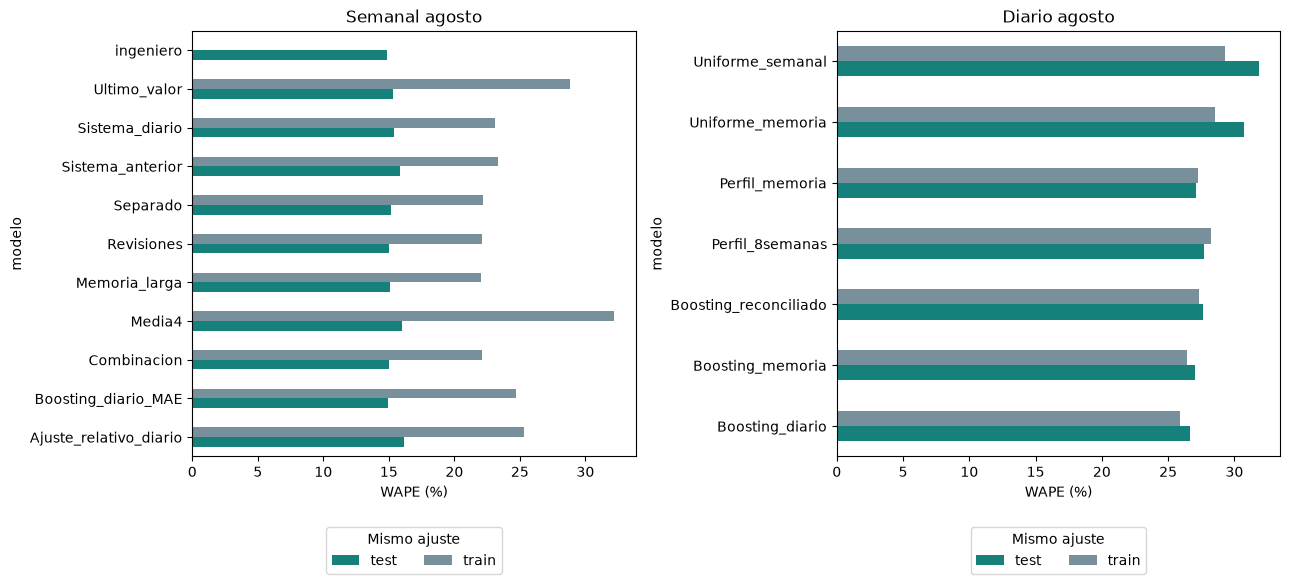

La evaluación fuera de entrenamiento es temporal y retrospectiva; la selección ya examinó 2026. No afirmar validación prospectiva intacta.


In [8]:
comparativa=pd.DataFrame(tablas)
comparativa.to_parquet(DESTINO/'diagnostico_train_test.parquet',index=False)
pares=comparativa.pivot(index=['escenario','modelo'],columns='split',values=['WAPE','n'])
display(pares)
full15=pd.read_excel(DESTINO/'resultados_experimentos_horizontes.xlsx',sheet_name='Resumen')
full14=pd.read_excel(DESTINO/'resultados_features_diarias_2026.xlsx',sheet_name='Resumen')
full12=pd.read_excel(DESTINO/'resultados_modelo_teorico.xlsx',sheet_name='Metricas_casos_comunes')
full_diario=pd.read_excel(DIARIO/'resultados_diarios_memoria.xlsx',sheet_name='Resumen')
full_sarima=pd.read_excel(DIARIO/'resultados_diarios_memoria.xlsx',sheet_name='Piloto_SARIMA')
for nombre,t in [('Semanal inicial: tres bloques',full12),('Semanal 2026: diarios',full14),('Semanal 2026: mejoras',full15),('Diario completo H1',full_diario),('Piloto de tres series',full_sarima)]:print(nombre);display(t)
with pd.ExcelWriter(DESTINO/'inventario_modelos_train_test.xlsx') as writer:
    comparativa.to_excel(writer,sheet_name='Train_test_cortes',index=False)
    pares.to_excel(writer,sheet_name='Comparacion_WAPE')
    for nombre,t in [('Test_completo_12',full12),('Test_completo_14',full14),('Test_completo_15',full15),('Test_completo_diario',full_diario),('Test_completo_SARIMA',full_sarima)]:t.to_excel(writer,sheet_name=nombre,index=False)
    pd.DataFrame(estados).to_excel(writer,sheet_name='Convergencia_snapshot',index=False)
fig,axs=plt.subplots(1,2,figsize=(13,6))
for ax,escenario in zip(axs,['Semanal_agosto','Diario_agosto']):
    t=comparativa.loc[comparativa.escenario.eq(escenario)].pivot(index='modelo',columns='split',values='WAPE').mul(100)
    t.plot.barh(ax=ax,color=['#16817a','#78909c']);ax.set_xlabel('WAPE (%)');ax.set_title(escenario.replace('_',' '));ax.legend(title='Mismo ajuste',loc='upper center',bbox_to_anchor=(.5,-.15),ncol=2)
fig.tight_layout();fig.savefig(ROOT/'Trabajo escrito/Figuras_resultados/train_test_modelos.png',dpi=170);plt.show()
print('La evaluación fuera de entrenamiento es temporal y retrospectiva; la selección ya examinó 2026. No afirmar validación prospectiva intacta.')

## 6. Alcance vigente del inventario

Los modelos iniciales (Ridge, boosting y ablaciones), referencias semanales y componentes diarios se reconstruyeron con clima actualizado. Las tablas ejecutadas contienen los errores vigentes por corte. El candidato climático de 19 y el sistema diario de 05 tienen sus propias tablas train/test; este inventario no los reemplaza. No confundir el train de un ajuste con el acumulado de test de todo 2026. El ingeniero no tiene train de nuestro algoritmo.